José Matheus Gonçalves Rodrigues  - 2171 - GEC


Estudo Aprofundado de Métodos de Classificação
em Machine Learning

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import confusion_matrix, classification_report

In [2]:
np.random.seed(42)

X_linear, y_linear = make_classification(
    n_samples=400,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=2.0,
    random_state=42
)

X_nonlinear, y_nonlinear = make_moons(
    n_samples=400,
    noise=0.25,
    random_state=42
)

In [3]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.grid(True)
    plt.show()

Exemplo 1 — Regressão Logística

Matriz de Confusão - Regressão Logística
[[63  3]
 [ 0 54]]

Relatório de Classificação
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        66
           1       0.95      1.00      0.97        54

    accuracy                           0.97       120
   macro avg       0.97      0.98      0.97       120
weighted avg       0.98      0.97      0.98       120



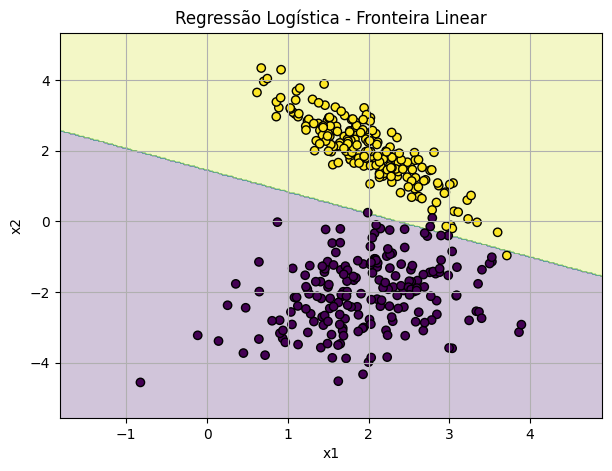

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_linear, y_linear, test_size=0.3, random_state=42
)

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)

print("Matriz de Confusão - Regressão Logística")
print(confusion_matrix(y_test, y_pred))

print("\nRelatório de Classificação")
print(classification_report(y_test, y_pred))
plot_decision_boundary(
    logistic_model,
    X_linear,
    y_linear,
    "Regressão Logística - Fronteira Linear"
)

A Regressão Logística foi aplicada em um conjunto de dados aproximadamente linearmente separável.
O modelo calcula uma combinação linear das entradas e usa a função sigmoide para transformar o resultado em probabilidade.
A fronteira de decisão é linear, por isso o modelo funciona bem quando as classes podem ser separadas por uma reta.

Exemplo 2 — KNN

Matriz de Confusão - KNN
[[60  0]
 [ 7 53]]

Relatório de Classificação
              precision    recall  f1-score   support

           0       0.90      1.00      0.94        60
           1       1.00      0.88      0.94        60

    accuracy                           0.94       120
   macro avg       0.95      0.94      0.94       120
weighted avg       0.95      0.94      0.94       120



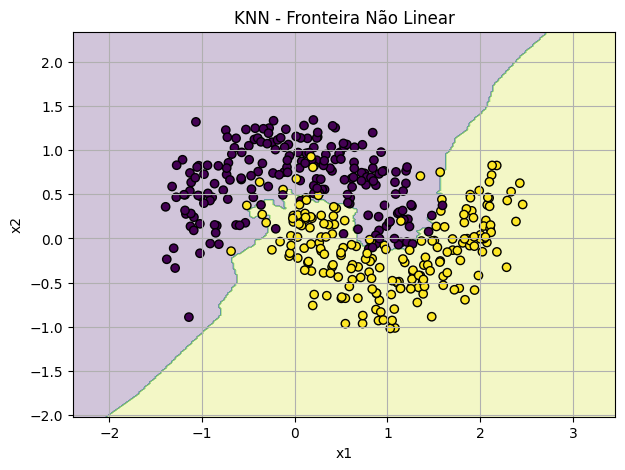

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_nonlinear, y_nonlinear, test_size=0.3, random_state=42
)

knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, y_train)

y_pred = knn_model.predict(X_test)

print("Matriz de Confusão - KNN")
print(confusion_matrix(y_test, y_pred))

print("\nRelatório de Classificação")
print(classification_report(y_test, y_pred))
plot_decision_boundary(
    knn_model,
    X_nonlinear,
    y_nonlinear,
    "KNN - Fronteira Não Linear"
)

O KNN classifica uma nova amostra com base nos vizinhos mais próximos.
Neste exemplo, foi utilizado k = 5. Como o conjunto de dados possui formato não linear, o KNN consegue criar uma fronteira de decisão curva e adaptada à distribuição local dos pontos.

Exemplo 3 — Árvore de Decisão

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_nonlinear, y_nonlinear, test_size=0.3, random_state=42
)

tree_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred = tree_model.predict(X_test)

print("Matriz de Confusão - Árvore de Decisão")
print(confusion_matrix(y_test, y_pred))

print("\nRelatório de Classificação")
print(classification_report(y_test, y_pred))

Matriz de Confusão - Árvore de Decisão
[[54  6]
 [ 7 53]]

Relatório de Classificação
              precision    recall  f1-score   support

           0       0.89      0.90      0.89        60
           1       0.90      0.88      0.89        60

    accuracy                           0.89       120
   macro avg       0.89      0.89      0.89       120
weighted avg       0.89      0.89      0.89       120



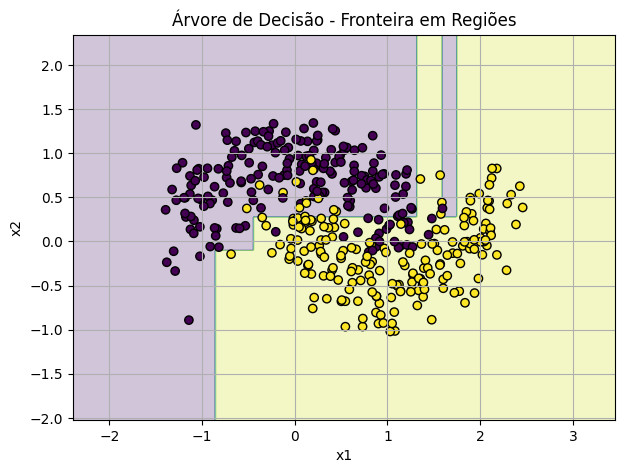

In [7]:
plot_decision_boundary(
    tree_model,
    X_nonlinear,
    y_nonlinear,
    "Árvore de Decisão - Fronteira em Regiões"
)

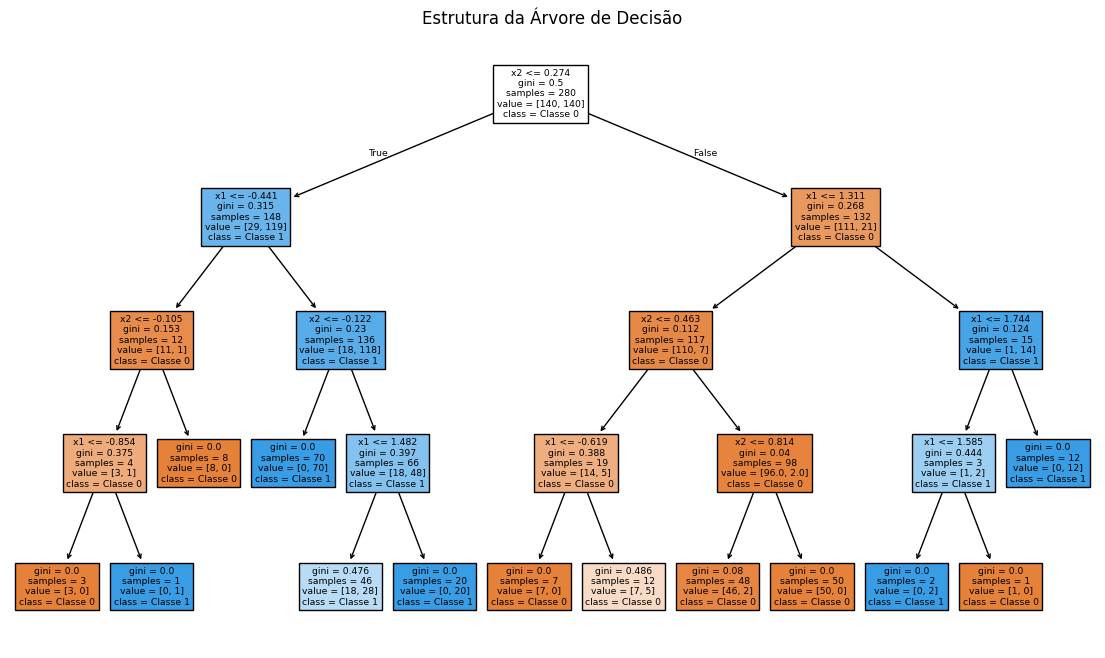

In [8]:
plt.figure(figsize=(14, 8))
plot_tree(
    tree_model,
    filled=True,
    feature_names=["x1", "x2"],
    class_names=["Classe 0", "Classe 1"]
)
plt.title("Estrutura da Árvore de Decisão")
plt.show()

A Árvore de Decisão divide o espaço de características por meio de regras do tipo x1 <= valor ou x2 <= valor.
O critério utilizado foi o índice de Gini, que mede a impureza dos nós.
A fronteira gerada é não linear, porém formada por regiões retangulares.

Exemplo 4 — Perceptron

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_linear, y_linear, test_size=0.3, random_state=42
)

perceptron_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Perceptron(
        max_iter=1000,
        eta0=0.1,
        random_state=42
    ))
])

perceptron_model.fit(X_train, y_train)

y_pred = perceptron_model.predict(X_test)

print("Matriz de Confusão - Perceptron")
print(confusion_matrix(y_test, y_pred))

print("\nRelatório de Classificação")
print(classification_report(y_test, y_pred))

Matriz de Confusão - Perceptron
[[64  2]
 [ 0 54]]

Relatório de Classificação
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        66
           1       0.96      1.00      0.98        54

    accuracy                           0.98       120
   macro avg       0.98      0.98      0.98       120
weighted avg       0.98      0.98      0.98       120



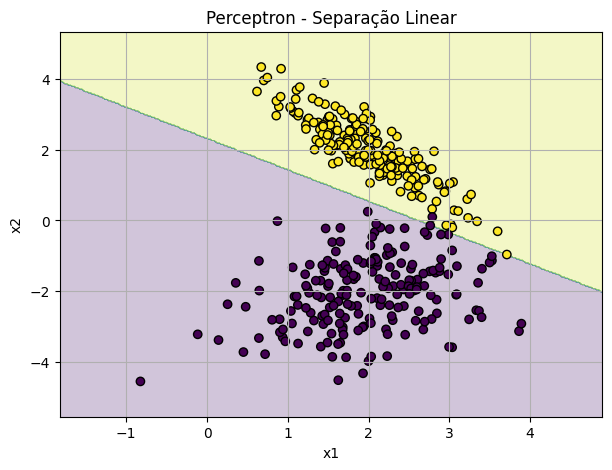

In [10]:
plot_decision_boundary(
    perceptron_model,
    X_linear,
    y_linear,
    "Perceptron - Separação Linear"
)

O Perceptron é um classificador linear inspirado em neurônios artificiais.
Ele ajusta seus pesos quando comete erros de classificação.
Como sua fronteira de decisão é linear, ele funciona melhor em problemas nos quais as classes podem ser separadas por uma reta.

Neste notebook foram comparados quatro métodos de classificação: Regressão Logística, KNN, Árvore de Decisão e Perceptron.

A Regressão Logística e o Perceptron apresentaram melhor comportamento em dados linearmente separáveis, pois ambos produzem fronteiras lineares. O KNN e a Árvore de Decisão conseguiram lidar melhor com dados não lineares, pois suas fronteiras se adaptam melhor à distribuição dos pontos.

Esse estudo mostra que não existe um único melhor algoritmo para todos os problemas. A escolha do modelo depende da estrutura dos dados, da necessidade de interpretabilidade, do custo computacional e do tipo de fronteira de decisão desejada.